# 🚢 Titanic: Machine Learning from Disaster
## Implementation of the CRISP-DM Framework
---

### 📋 Project Abstract
This project implements a comprehensive machine learning workflow to predict passenger survival. I have focused on building a scalable **Scikit-Learn Pipeline** that automates data transformation and model training while ensuring rigorous validation through stratified sampling and hyperparameter optimization.

**[View Full Project README.md](./README.md)**

### 🛠️ Strategic Summary
1.  **Objective:** Optimize Log-Loss through a non-linear Random Forest ensemble.
2.  **Data Integrity:** Implemented a unified `ColumnTransformer` to handle nulls and encoding without leakage.
3.  **Optimization:** Leveraged `GridSearchCV` to identify optimal tree depth and estimator count.
4.  **Performance:** 83.43% validation accuracy, verified via Learning Curve diagnostics.

---

# 1- Exploratory Data Analysis

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
titanic_data = pd.read_csv('train.csv')
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


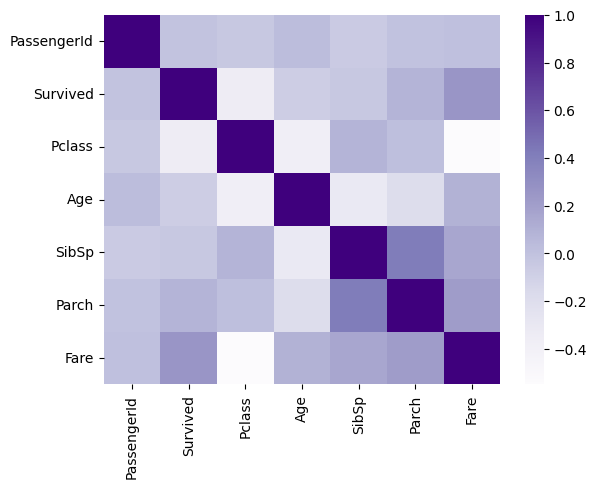

In [3]:
sns.heatmap(titanic_data.corr(numeric_only=True), cmap="Purples")
plt.show()

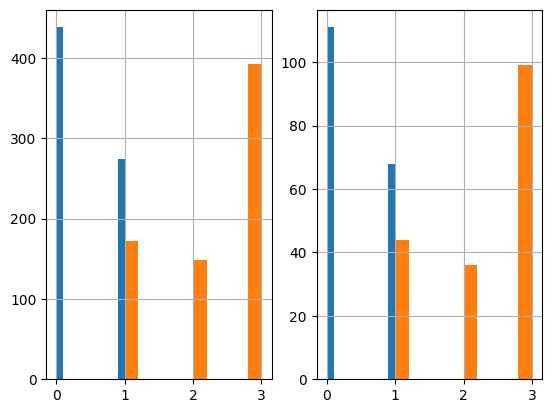

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits= 1, test_size= 0.2)
indices = split.split(titanic_data, titanic_data[["Survived","Pclass", "Sex"]])

for train_index, test_index in indices:
    train_set = titanic_data.loc[train_index]
    test_set = titanic_data.loc[test_index]  

plt.subplot(1, 2, 1)
train_set['Survived'].hist()
train_set['Pclass'].hist()

plt.subplot(1, 2, 2)
test_set['Survived'].hist()
test_set['Pclass'].hist()

plt.show()


Since the Titanic project is a binary classification problem,
I identified Log-Loss as the appropriate cost function.
I chose the Random Forest algorithm specifically because it optimizes for non-linear relationships and is robust against the outliers found in the 'Fare' and 'Age' columns.

# 2- Data Preparation

In [5]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 57 to 430
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          577 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        156 non-null    object 
 11  Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [6]:
X_train= train_set.drop('Survived', axis=1)
y_train= train_set['Survived']

X_test= test_set.drop('Survived', axis=1)
y_test= test_set['Survived']

In [7]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier

numerical_features = ['Pclass', 'Age', 'Fare']
categorical_features = ['Sex', 'Cabin', 'Embarked']

numerical_pipeline = Pipeline([
    ('impute_step', SimpleImputer()),
    ('scale_step', StandardScaler())
    ])
categorical_pipeline = make_pipeline(SimpleImputer(strategy = 'most_frequent'),
                                     OneHotEncoder(handle_unknown='ignore'))

prepocessor = make_column_transformer(
    (numerical_pipeline, numerical_features),
    (categorical_pipeline, categorical_features))

model = make_pipeline(prepocessor, RandomForestClassifier())


# 3- Modeling

In [8]:
model = model.fit(X_train,y_train)

accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 80.45%


# 4- Evaluation and Optimization

In [30]:
from sklearn.model_selection import cross_val_score

cross_val_score(model,X_train, y_train, cv=5, scoring='accuracy')

array([0.81818182, 0.76223776, 0.78873239, 0.78873239, 0.85211268])

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'randomforestclassifier__n_estimators': [200, 400, 500, 600],
    'randomforestclassifier__max_depth': [10, 12, 15]
}


grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

final_model = grid_search.best_estimator_

In [29]:
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Model Accuracy: {model.score(X_test, y_test) * 100:.2f}%")
print(f"final Model Accuracy: {grid_search.best_score_ * 100:.2f}%")
cross_val_score(final_model,X_train, y_train, cv=5, scoring='accuracy')

Best Hyperparameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__n_estimators': 600}
Model Accuracy: 80.45%
final Model Accuracy: 83.43%


array([0.83216783, 0.82517483, 0.79577465, 0.83098592, 0.83802817])

In [38]:
from sklearn.metrics import confusion_matrix

y_pred = final_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))



[[102   9]
 [ 21  47]]


[ 56 113 170 227 284 341 398 455 512 569]


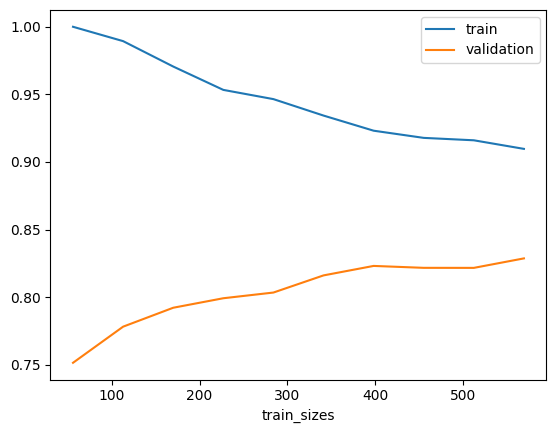

In [42]:
from sklearn.model_selection import learning_curve

N, train_score, val_score = learning_curve(final_model, X_train, y_train, train_sizes= np.linspace(0.1, 1.0, 10), cv=5)

print(N)
plt.plot(N, train_score.mean(axis=1), label = 'train')
plt.plot(N, val_score.mean(axis=1), label = 'validation')
plt.xlabel('train_sizes')
plt.legend()

In [43]:
X= titanic_data.drop('Survived', axis=1)
y= titanic_data['Survived']
model_v2 = model.fit(X,y)

In [47]:
final_grid_search = GridSearchCV(model_v2, param_grid, cv=5)
final_grid_search.fit(X, y)

model_v2 = grid_search.best_estimator_

In [48]:
print(f"Best Hyperparameters: {final_grid_search.best_params_}")
cross_val_score(model_v2,X, y, cv=5, scoring='accuracy')


print(f"Model 1 Accuracy: {grid_search.best_score_ * 100:.2f}%")
print(f"Model 2 Accuracy: {final_grid_search.best_score_ * 100:.2f}%")


Best Hyperparameters: {'randomforestclassifier__max_depth': 15, 'randomforestclassifier__n_estimators': 400}
Model 1 Accuracy: 83.43%
Model 2 Accuracy: 83.16%


In [46]:
titanic_test_data = pd.read_csv('test.csv')

In [53]:
predictions = model_v2.predict(titanic_test_data)

submission = pd.DataFrame({
    "PassengerId": titanic_test_data["PassengerId"],
    "Survived": predictions
})

submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [54]:
submission.to_csv('titanic_submission.csv', index=False)

In [55]:
import joblib

joblib.dump(model_v2, 'titanic_survival_model.pkl')

['titanic_survival_model.pkl']